In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

Infosys Data

In [2]:
data = yf.download("INFY.NS", start="2018-01-01", auto_adjust=True)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.columns.name = None
data.tail()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,1315.000000,1318.000000,1282.500000,1290.0,10068514
2026-03-10,1295.599976,1321.000000,1284.099976,1320.0,9600171
2026-03-11,1276.300049,1299.500000,1271.300049,1288.0,7868891
2026-03-12,1265.800049,1278.599976,1258.000000,1272.5,7599940
2026-03-13,1248.300049,1269.599976,1242.599976,1251.0,7365621


In [3]:
data["simple_return"] = data["Close"].pct_change()

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()

data

,Close,High,Low,Open,Volume,simple_return,log_return
Date,,,,,,,
2018-01-02,413.697388,418.639117,411.005582,416.730733,6112248,-0.003725,-0.003732
2018-01-03,410.322632,414.460807,409.237861,413.215345,6846552,-0.008158,-0.008191
2018-01-04,407.952179,410.202053,405.621922,410.202053,8947614,-0.005777,-0.005794
2018-01-05,406.586212,412.371638,404.175622,407.912032,11025976,-0.003348,-0.003354
2018-01-08,416.248718,417.433906,409.820453,411.769028,5594690,0.023765,0.023487
...,...,...,...,...,...,...,...
2026-03-09,1315.000000,1318.000000,1282.500000,1290.000000,10068514,0.005044,0.005032
2026-03-10,1295.599976,1321.000000,1284.099976,1320.000000,9600171,-0.014753,-0.014863
2026-03-11,1276.300049,1299.500000,1271.300049,1288.000000,7868891,-0.014897,-0.015009


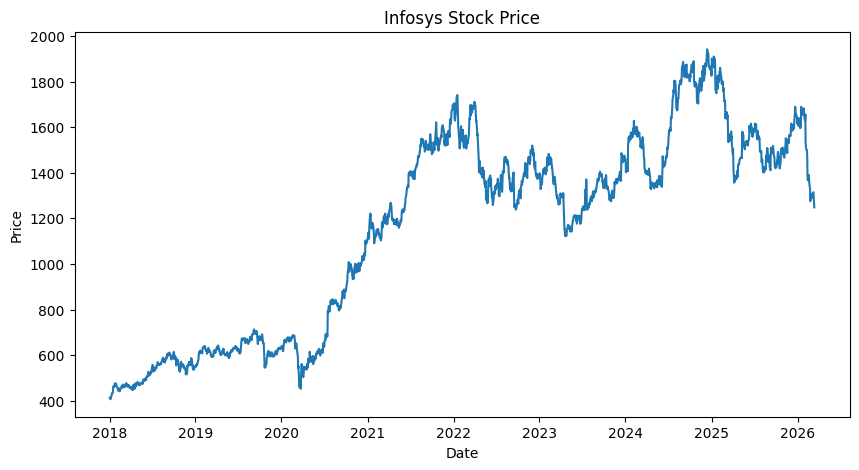

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data["Close"])
plt.title("Infosys Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Volatility Analysis

In [5]:
daily_volatility = data["log_return"].std()

annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annual Volatility:", annual_volatility)

Daily Volatility: 0.017180395985901244
Annual Volatility: 0.2727303312258423


Sharpe Ratio

In [6]:
annual_return = data["log_return"].mean() * 252

risk_free_rate = 0.07

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Annual Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.13697240173558053
Sharpe Ratio: 0.24556271916863578


Beta Calculation (Market Risk)

In [7]:
# Download NIFTY market data
market = yf.download("^NSEI", start="2018-01-01", auto_adjust=True)

# Fix column structure if needed
if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

# Calculate market returns
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

# Merge Infosys and market returns
df = pd.concat([data["log_return"], market["market_return"]], axis=1).dropna()

# Regression
X = sm.add_constant(df["market_return"])
y = df["log_return"]

model = sm.OLS(y, X).fit()

# Get Beta (correct way)
beta = model.params["market_return"]

print("Beta:", beta)

[*********************100%***********************]  1 of 1 completed

Beta: 0.8329828900093607


Value at Risk (VaR)

In [8]:
VaR_95 = np.percentile(data["log_return"], 5)

print("95% Value at Risk:", VaR_95)

95% Value at Risk: -0.02479040625952422


Stationarity Test (ADF)

In [9]:
result = adfuller(data["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -16.708653321676746
p-value: 1.440827887849731e-29


ARIMA Model

In [10]:
model = ARIMA(data["log_return"], order=(1,0,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2025
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5357.068
Date:                Sat, 14 Mar 2026   AIC                         -10706.137
Time:                        11:00:35   BIC                         -10683.683
Sample:                             0   HQIC                        -10697.897
                               - 2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.416      0.157      -0.000       0.001
ar.L1         -0.0027      0.788     -0.003      0.997      -1.547       1.541
ma.L1         -0.0161      0.790     -0.020      0.9

Forecast Future Returns

In [11]:
forecast = model_fit.forecast(steps=5)

print("Next 5 day forecast:")

print(forecast)

Next 5 day forecast:
2025    0.000817
2026    0.000541
2027    0.000541
2028    0.000541
2029    0.000541
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Return Distribution

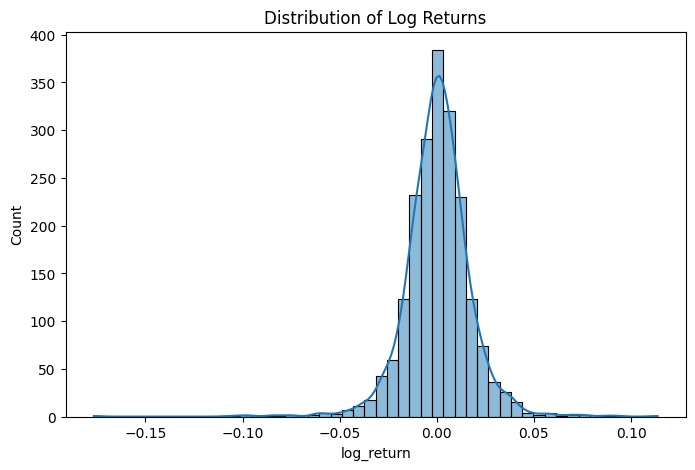

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(data["log_return"], bins=50, kde=True)

plt.title("Distribution of Log Returns")

plt.show()

Performance Analysis using Pyfolio

In [13]:
!pip install pyfolio-reloaded

In [14]:
import pyfolio as pf
import pandas as pd
import numpy as np
import yfinance as yf

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


**Download Benchmark Data (NIFTY 50)**

To evaluate the performance of the stock relative to the market, we use the NIFTY 50 index as a benchmark.

In [15]:
market = yf.download("^NSEI", start="2018-01-01", auto_adjust=True)

# fix multiindex if present
if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

# display market table
market.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,24028.050781,24078.150391,23697.800781,23868.050781,526900
2026-03-10,24261.599609,24303.800781,24079.949219,24280.800781,444300
2026-03-11,23866.849609,24299.000000,23834.300781,24231.849609,407400
2026-03-12,23639.150391,23833.150391,23556.300781,23674.849609,501000
2026-03-13,23151.099609,23492.400391,23112.000000,23462.500000,0


**Compute Benchmark Returns**

We compute log returns for the benchmark index to ensure consistency with the stock returns used earlier.

In [16]:
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

benchmark_returns = market["market_return"].dropna()

benchmark_returns.head()

,market_return
Date,
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114
2018-01-09,0.001261


**Prepare Stock Returns**

Pyfolio requires a clean return series indexed by datetime.

We remove timezone information and ensure the data is aligned properly.


**Generate Pyfolio Performance Report**


The Pyfolio tear sheet provides a comprehensive summary of portfolio performance including:


*   cumulative returns

*   drawdown periods

*   rolling Sharpe ratio

*   volatility analysis

*   return distribution





[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.055%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-03
End date,2026-03-13
Total months,96
,Backtest
Annual return,10.055%
Cumulative returns,115.548%
Annual volatility,27.297%
Sharpe ratio,0.49
Calmar ratio,0.25
Stability,0.68
Max drawdown,-40.941%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,40.94,2019-09-06,2020-03-23,2020-07-20,227
1,38.61,2022-01-17,2023-04-20,2024-12-11,758
2,38.29,2024-12-13,2026-03-13,NaT,NaN
3,16.80,2018-10-01,2018-11-21,2019-02-01,90
4,10.82,2021-01-13,2021-01-29,2021-04-05,59


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


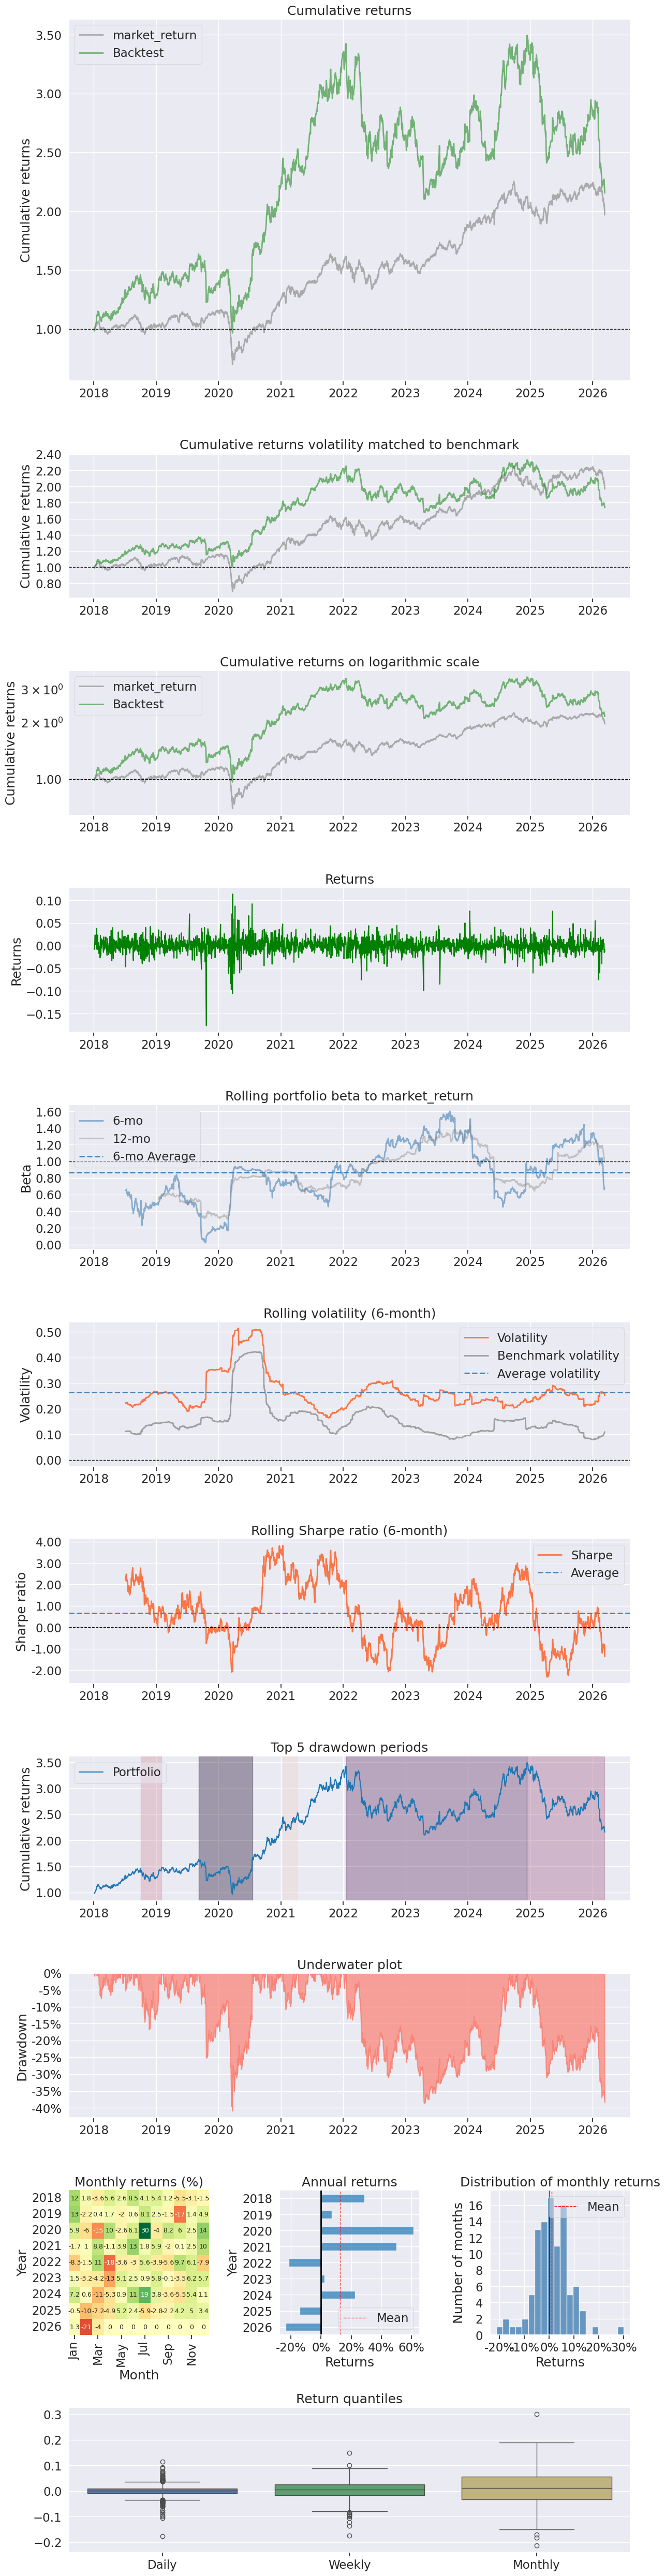

In [17]:
import pyfolio as pf
import pandas as pd
import numpy as np
import yfinance as yf

# Redefine data (from cell Mu8ZsVI1j348 and eO1lNPdekIdF)
data = yf.download("INFY.NS", start="2018-01-01", auto_adjust=True)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.columns.name = None
data["simple_return"] = data["Close"].pct_change()
data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))
data = data.dropna()

# Redefine market (from cell J1MJ0emFl-eK)
market = yf.download("^NSEI", start="2018-01-01", auto_adjust=True)
if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

# Re-define returns and benchmark_returns for robustness
returns = data["log_return"]
benchmark_returns = market["market_return"].dropna()

# Localize indices
returns.index = returns.index.tz_localize(None)
benchmark_returns.index = benchmark_returns.index.tz_localize(None)

pf.create_returns_tear_sheet(
    returns,
    benchmark_rets=benchmark_returns
)

**Rolling Volatility**

Rolling volatility helps visualize how risk evolves over time.

<Axes: title={'center': 'Rolling volatility (6-month)'}, ylabel='Volatility'>

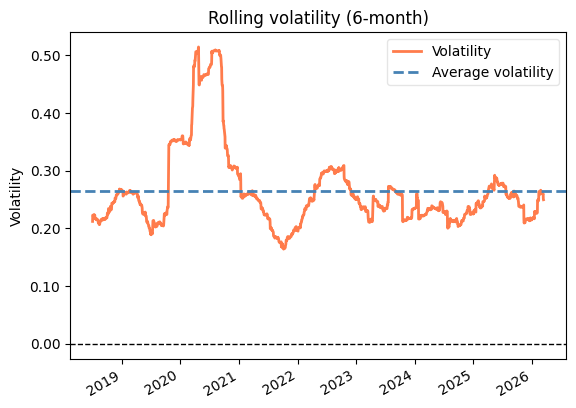

In [18]:

pf.plotting.plot_rolling_volatility(returns)

**Rolling Sharpe Ratio**

This plot shows how the risk-adjusted return changes through time.

<Axes: title={'center': 'Rolling Sharpe ratio (6-month)'}, ylabel='Sharpe ratio'>

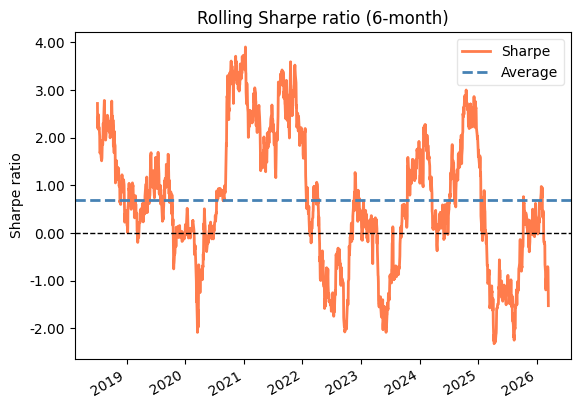

In [19]:
pf.plotting.plot_rolling_sharpe(returns)

**Drawdown Analysis**

Drawdown represents the decline from a historical peak.

This helps identify periods of large losses.

<Axes: title={'center': 'Top 10 drawdown periods'}, ylabel='Cumulative returns'>

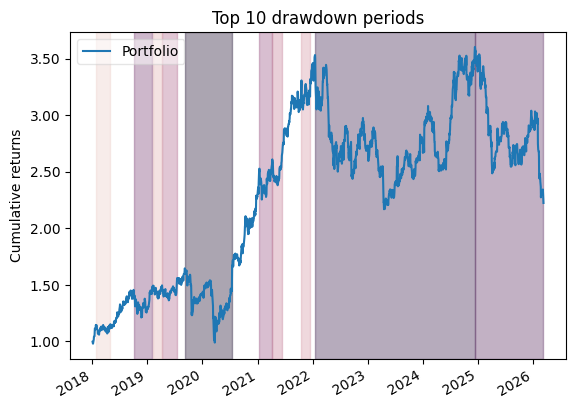

In [20]:
pf.plotting.plot_drawdown_periods(returns)

Rolling metrics

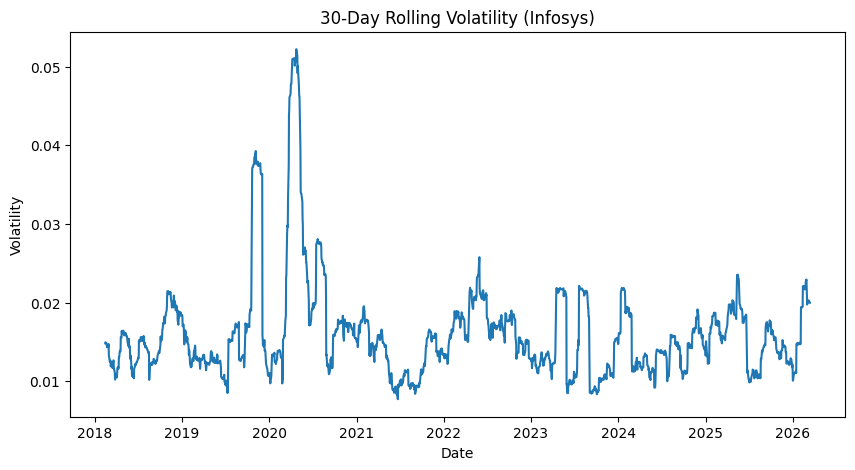

In [22]:
data["rolling_vol"] = data["log_return"].rolling(30).std()

plt.figure(figsize=(10,5))
plt.plot(data["rolling_vol"])
plt.title("30-Day Rolling Volatility (Infosys)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

Maximum Drawdown

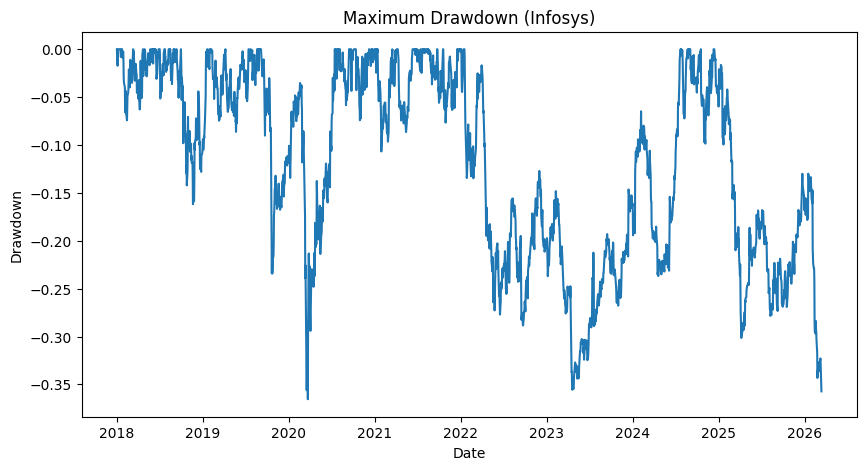

In [23]:
# Maximum Drawdown

cum_returns = (1 + data["simple_return"]).cumprod()

rolling_max = cum_returns.cummax()

drawdown = cum_returns / rolling_max - 1

plt.figure(figsize=(10,5))
plt.plot(drawdown)
plt.title("Maximum Drawdown (Infosys)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

Cumulative Return

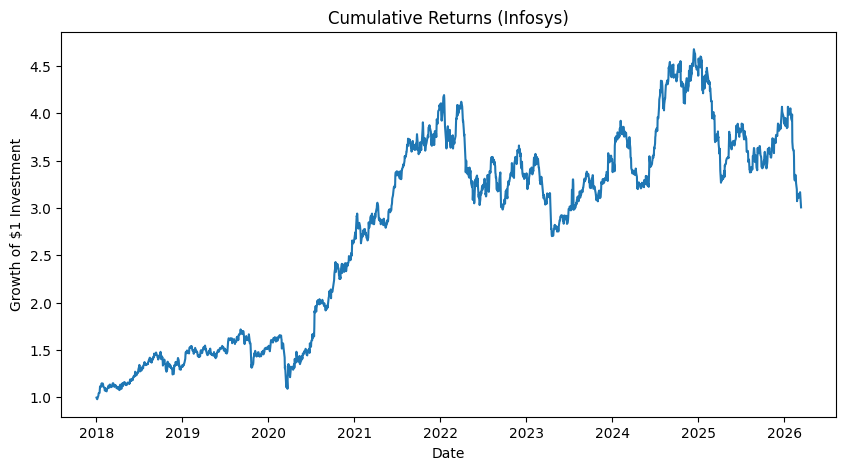

In [24]:
# Cumulative Returns

cum_returns = (1 + data["simple_return"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_returns)
plt.title("Cumulative Returns (Infosys)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.show()